In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import m_e, e ,c 
from astropy import units as u
from scipy.constants import physical_constants
from scipy.constants import physical_constants, c as cc

In [2]:
N = 1000
xx = np.linspace(1530, 1560, N)
cc = c.to(u.cm / u.s).value  # cm/s
nu = cc / (xx*1e-8)
print(nu[0] , nu[-1])

1959427830065359.5 1921746525641025.8


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import m_e, e ,c 
from astropy import units as u
from scipy.constants import physical_constants
from scipy.constants import physical_constants, c as cc

C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

C_IV_K_A = 1548.187  # cm
C_IV_H_A = 1550.772  # cm

cc = c.to(u.cm / u.s).value  # cm/s
cc_k = c.to(u.km / u.s).value #km / s
v_th_CIV = 11.7673179819719e5  # cm/s

K_gamma = 2.65e+8
H_gamma = 2.64e+8
f_CIV_K = 0.190
f_CIV_H = 0.0952



from scipy.integrate import simps

def voigt(lambda_x, v_th, line_K, line_gamma_K, f_K):
    delta_D = v_th / line_K  #1/s

    a = line_gamma_K / (np.pi * 4 * delta_D) 

    yy_x = np.arange(-50, 50, 0.001)  # dx를 0.001로 설정
    dy = abs(yy_x[1] - yy_x[0])
    sol = np.zeros(len(lambda_x))
    x_K = np.zeros(len(lambda_x))

    # Precompute exp(-yy_x^2) since it doesn't depend on xx
    exp_u = np.exp(-yy_x**2)

    for ii, xx in enumerate(lambda_x):
        x = ( (line_K) / (xx*1e-8) -1  ) * cc / delta_D
        exp_d = (x - yy_x)**2 + a**2
        exp = exp_u / exp_d

        # 기존 sum 대신 simps 사용
        F_lamb = simps(exp, yy_x)

        sol[ii] = F_lamb
        x_K[ii] = x

    return x_K, sol * a / np.pi, delta_D


xx = np.arange(1530,1560,0.001)

# Usage with existing variables (assuming they are already defined)
xx_K, voigt_K, delta_D_K = voigt(xx, v_th_CIV, C_IV_K, K_gamma, f_CIV_K)
xx_H, voigt_H, delta_D_H = voigt(xx, v_th_CIV, C_IV_H, H_gamma, f_CIV_H)
vel_x = (xx / C_IV_K_A - 1) * cc_k 


# Usage with existing variables (assuming they are already defined)
# xx_K, voigt_K, delta_D_K = voigt(xx, v_th_CIV, C_IV_K, K_gamma, f_CIV_K)
# xx_H, voigt_H, delta_D_H = voigt(xx, v_th_CIV, C_IV_H, H_gamma, f_CIV_H)
# vel_x = (xx / C_IV_K_A - 1) * cc_k 

def scs(voigt_K,delta_D_K, voigt_H,delta_D_H, f_K, f_H):
    r_e = physical_constants["classical electron radius"][0]* 1e2   # cm
    const= (r_e * cc) * np.sqrt(np.pi) /  (f_K + f_H)
    K_term = (f_K/delta_D_K) * voigt_K
    H_term = (f_H/delta_D_H) * voigt_H
    cross = const*(K_term + H_term)
    return cross

# v_th_1 = 2.5e5
# xx_K_1, voigt_K_1, delta_D_K_1 = voigt(xx, v_th_1, C_IV_K, K_gamma, f_CIV_K)
# xx_H_1, voigt_H_1, delta_D_H_1 = voigt(xx, v_th_1, C_IV_H, H_gamma, f_CIV_H)

v_th_2 = 30e5
xx_K_2, voigt_K_2, delta_D_K_2 = voigt(xx, v_th_2, C_IV_K, K_gamma, f_CIV_K)
xx_H_2, voigt_H_2, delta_D_H_2 = voigt(xx, v_th_2, C_IV_H, H_gamma, f_CIV_H)


v_th_3 = 50e5
xx_K_3, voigt_K_3, delta_D_K_3 = voigt(xx, v_th_3, C_IV_K, K_gamma, f_CIV_K)
xx_H_3, voigt_H_3, delta_D_H_3 = voigt(xx, v_th_3, C_IV_H, H_gamma, f_CIV_H)

cross_sec = scs(voigt_K,delta_D_K,voigt_H,delta_D_H,f_CIV_K,f_CIV_H)
# cross_sec_1 = scs(voigt_K_1,delta_D_K_1,voigt_H_1,delta_D_H_1,f_CIV_K,f_CIV_H)
cross_sec_2 = scs(voigt_K_2,delta_D_K_2,voigt_H_2,delta_D_H_2,f_CIV_K,f_CIV_H)
cross_sec_3 = scs(voigt_K_3,delta_D_K_3,voigt_H_3,delta_D_H_3,f_CIV_K,f_CIV_H)




/tmp/ipykernel_38570/4077307698.py:46: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  F_lamb = simps(exp, yy_x)


KeyboardInterrupt: 

In [23]:
import numpy as np
from scipy.special import wofz
from scipy.constants import physical_constants
from astropy.constants import c
from astropy import units as u

C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm
C_IV_K_A = 1548.187
C_IV_H_A = 1550.772

cc = c.to(u.cm / u.s).value
cc_k = c.to(u.km / u.s).value

K_gamma = 2.65e8
H_gamma = 2.64e8
f_CIV_K = 0.190
f_CIV_H = 0.0952


def voigt_fast(lambda_x, v_th, line_cm, gamma):
    # Doppler width in frequency
    delta_D = v_th / line_cm   # [1/s]

    # dimensionless damping parameter
    a = gamma / (4.0 * np.pi * delta_D)

    # dimensionless frequency offset x
    nu = cc / (lambda_x * 1e-8)   # lambda_x is in Angstrom
    nu0 = cc / line_cm
    x = (nu - nu0) / delta_D

    # Hjerting / Voigt function H(a,x)
    H = np.real(wofz(x + 1j * a))

    return x, H, delta_D


def scs(voigt_K, delta_D_K, voigt_H, delta_D_H, f_K, f_H):
    r_e = physical_constants["classical electron radius"][0] * 1e2  # cm
    const = (r_e * cc) * np.sqrt(np.pi) / (f_K + f_H)
    K_term = (f_K / delta_D_K) * voigt_K
    H_term = (f_H / delta_D_H) * voigt_H
    cross = const * (K_term + H_term)
    return cross


xx = np.arange(1500, 1600, 0.001)
vel_x = (xx / C_IV_K_A - 1) * cc_k 
xx_K, voigt_K, delta_D_K = voigt_fast(xx, 11.7673179819719e5, C_IV_K, K_gamma)
xx_H, voigt_H, delta_D_H = voigt_fast(xx, 11.7673179819719e5, C_IV_H, H_gamma)

xx_K_2, voigt_K_2, delta_D_K_2 = voigt_fast(xx, 30e5, C_IV_K, K_gamma)
xx_H_2, voigt_H_2, delta_D_H_2 = voigt_fast(xx, 30e5, C_IV_H, H_gamma)

xx_K_3, voigt_K_3, delta_D_K_3 = voigt_fast(xx, 50e5, C_IV_K, K_gamma)
xx_H_3, voigt_H_3, delta_D_H_3 = voigt_fast(xx, 50e5, C_IV_H, H_gamma)

cross_sec   = scs(voigt_K,   delta_D_K,   voigt_H,   delta_D_H,   f_CIV_K, f_CIV_H)
cross_sec_2 = scs(voigt_K_2, delta_D_K_2, voigt_H_2, delta_D_H_2, f_CIV_K, f_CIV_H)
cross_sec_3 = scs(voigt_K_3, delta_D_K_3, voigt_H_3, delta_D_H_3, f_CIV_K, f_CIV_H)

7.62e+12


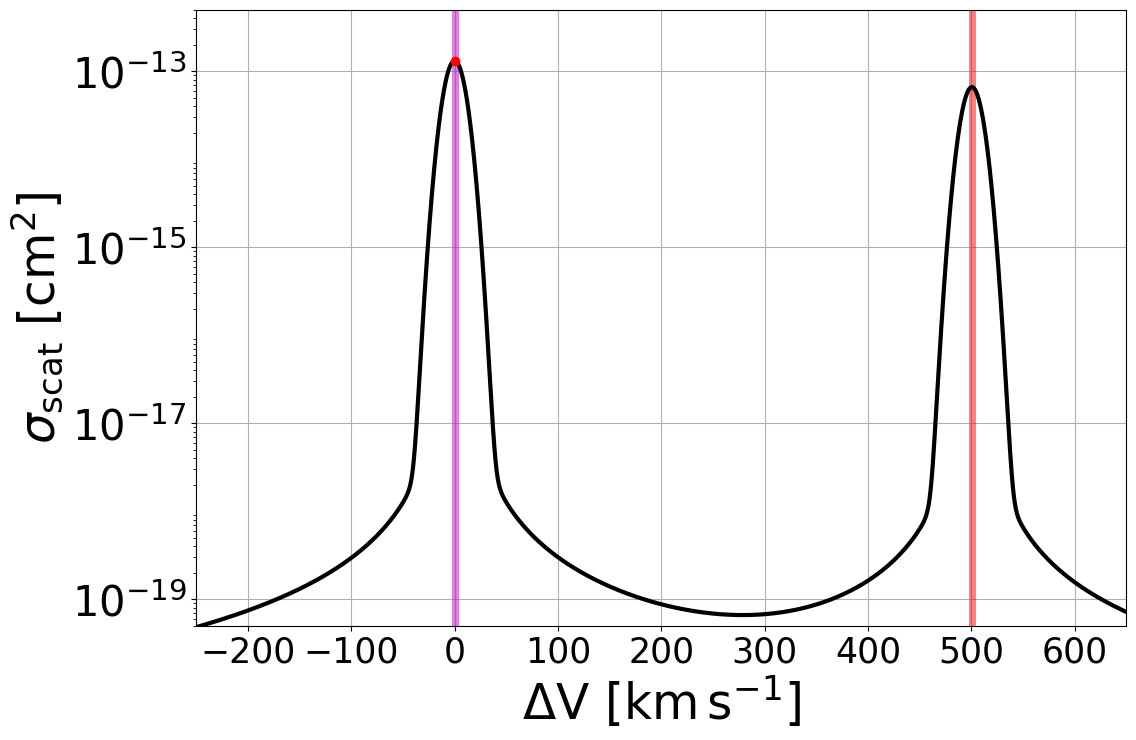

In [24]:
fig = plt.figure(1,figsize=(12,8))

# plt.plot(vel_x,cross_sec_1,'k:',alpha=1,lw=3,label=r'$\sigma_{\rm R} = 2.5 ~ [\rm km\,s^{-1}]$')
# plt.plot(vel_x, cross_sec_2, 'b-', markersize=0.5,label=r'30.0')
# plt.plot(vel_x, cross_sec_3, 'r-', markersize=0.5,label=r'50.0 ')
HH = (C_IV_H_A/ C_IV_K_A -1 ) *cc_k
plt.axvline(0,ymin=-1,ymax=1,linestyle='-',color='m',alpha=0.5,lw=5)
plt.axvline(HH,ymin=-1,ymax=1,linestyle='-',color='r',alpha=0.5,lw=5)
plt.yscale('log')

# vel_x = xx*(11.8)

plt.plot(vel_x,cross_sec,'k-',lw=3,alpha=1,label=r'$ 11.8 $')
plt.xlim(-250,650)
plt.ylim(0.5e-19,5e-13)
plt.ylabel(r'$\sigma_{\rm scat} ~ [\rm cm^{2}]$',fontsize=35)
plt.xlabel(r'$\Delta \rm V ~ [\rm km \, s^{-1}]$',fontsize=35)
plt.yticks([10e-20,10e-18,10e-16,10e-14],fontsize=30)
plt.xticks(fontsize=25)

y0 = np.interp(0.0, vel_x, cross_sec)
print(f'{1 / y0:.2e}')
plt.plot(0.0, y0, 'ro')

# plt.savefig('/home/jin/바탕화면/Scattering cross_section.png',bbox_inches='tight')
# plt.axhline(y=1e-14,xmin=0,xmax=1,linestyle='--')
# a = np.argmax(cross_sec)
# print(1 / max(cross_sec))
plt.grid(True)
# plt.legend(loc='upper right',fontsize=25 , title=r'$\sigma_R ~ [\rm km \, s^{-1}]$',title_fontsize=30)

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from astropy.constants import c
# from astropy import units as u
# from scipy.constants import physical_constants

# C_IV_K = 1548.187e-8  # cm
# C_IV_H = 1550.772e-8  # cm

# C_IV_K_A = 1548.187  # Å
# C_IV_H_A = 1550.772  # Å

# cc = c.to(u.cm / u.s).value  # cm/s
# cc_k = c.to(u.km / u.s).value # km/s
# v_th_CIV = 11.7673179819719e5  # cm/s

# K_gamma = 2.65e+8
# H_gamma = 2.64e+8
# f_CIV_K = 0.190
# f_CIV_H = 0.0952

# def voigt(lambda_x, v_th, line_K, line_gamma_K, f_K):
#     delta_D = v_th / line_K  # Doppler width (1/s)

#     a = line_gamma_K / (np.pi * 4 * delta_D)  # Voigt parameter

#     yy_x = np.arange(-100, 100, 0.0001)  # 적분 범위 확장 가능
#     dy = abs(yy_x[1] - yy_x[0])
#     sol = np.zeros(len(lambda_x))
#     x_K = np.zeros(len(lambda_x))

#     exp_u = np.exp(-yy_x**2)  # Precompute exp(-yy_x^2)

#     for ii, xx in enumerate(lambda_x):
#         x = ((line_K) / (xx * 1e-8) - 1) * cc / v_th_CIV
#         exp_d = (x - yy_x) ** 2 + a ** 2
#         exp = exp_u / exp_d

#         # 기존 sum 대신 np.trapz() 사용
#         F_lamb = np.trapz(exp, yy_x)

#         sol[ii] = F_lamb
#         x_K[ii] = x

#     return x_K, sol * a / np.pi, delta_D

# xx = np.arange(1520, 1580, 0.001)
# xx_K, voigt_K, delta_D_K = voigt(xx, v_th_CIV, C_IV_K, K_gamma, f_CIV_K)
# xx_H, voigt_H, delta_D_H = voigt(xx, v_th_CIV, C_IV_H, H_gamma, f_CIV_H)
# vel_x = (xx / C_IV_K_A - 1) * cc_k 

# def scs(voigt_K, delta_D_K, voigt_H, delta_D_H, f_K, f_H):
#     r_e = physical_constants["classical electron radius"][0] * 1e2  # cm
#     const = (r_e * cc) * np.sqrt(np.pi) 
#     K_term = (f_K / delta_D_K) * voigt_K
#     H_term = (f_H / delta_D_H) * voigt_H
#     cross = const * (K_term + H_term)
#     return cross

# cross_sec = scs(voigt_K, delta_D_K, voigt_H, delta_D_H, f_CIV_K, f_CIV_H)


KeyboardInterrupt: 

In [ ]:
# r_e = physical_constants["classical electron radius"][0]* 1e2
# r_e

2.8179403262e-13

In [ ]:
# e = 1.602e-19*3e9
# c = 2.99792458e10

# m_e = 9.10938356e-28

# print(e**2 / (m_e *c))
# print(r_e * c)

0.008457808371784338
0.008447972568888197


In [ ]:
# plt.plot(vel_x,cross_sec,'k-',label=r'$\sigma_{\rm R} = 11.8 ~ [\rm km\,s^{-1}]$')
# HH = (C_IV_H_A/ C_IV_K_A -1 ) *cc_k
# plt.axvline(0,ymin=-1,ymax=1,linestyle='--',color='g',alpha=0.5)
# plt.axvline(HH,ymin=-1,ymax=1,linestyle='--',color='g',alpha=0.5)
# plt.yscale('log')
# plt.xlim(-700,1500)
# plt.ylim(0.5e-20,1e-12)
# plt.ylabel(r'$\sigma_{\rm scr} ~ [\rm cm^{2}]$',fontsize=20)
# plt.xlabel(r'$\Delta V [\rm km s^{-1}]$',fontsize=20)
# plt.yticks([10e-20,10e-18,10e-16,10e-14,10e-12],fontsize=15)
# plt.xticks(fontsize=15)
# plt.legend(loc='lower left',fontsize=20)

1.3120232446665972e-13


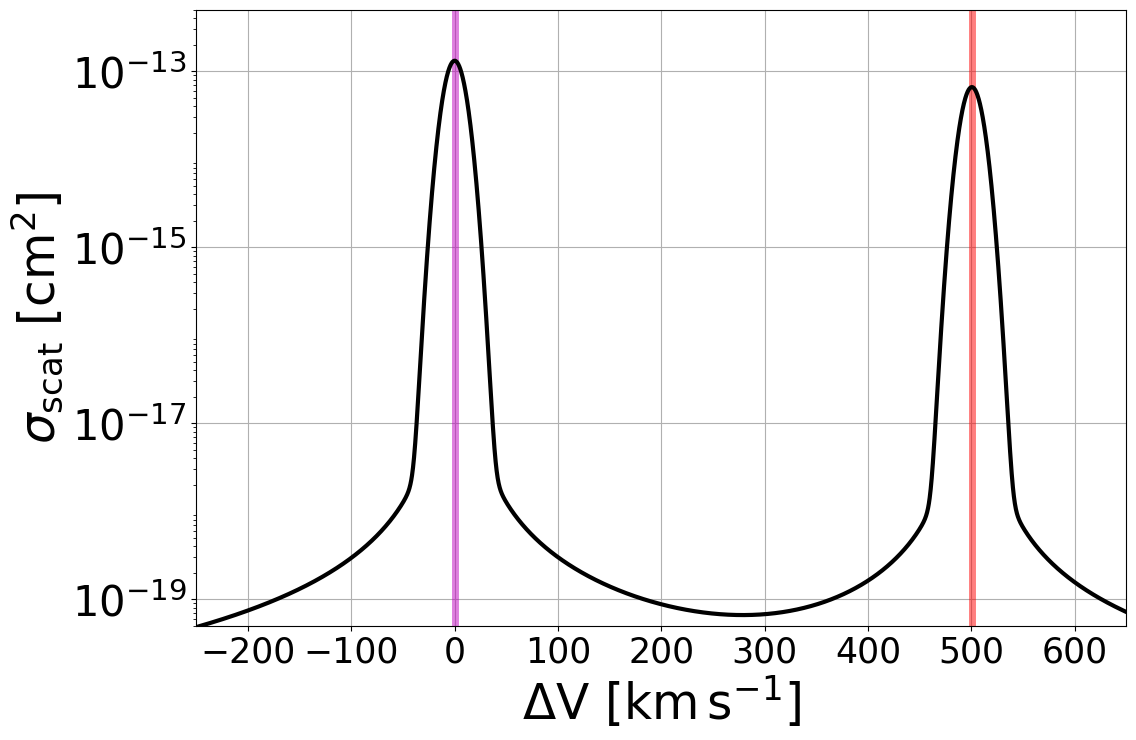

In [ ]:
fig = plt.figure(1,figsize=(12,8))

# plt.plot(vel_x,cross_sec_1,'k:',alpha=1,lw=3,label=r'$\sigma_{\rm R} = 2.5 ~ [\rm km\,s^{-1}]$')
# plt.plot(vel_x, cross_sec_2, 'b-', markersize=0.5,label=r'30.0')
# plt.plot(vel_x, cross_sec_3, 'r-', markersize=0.5,label=r'50.0 ')
HH = (C_IV_H_A/ C_IV_K_A -1 ) *cc_k
plt.axvline(0,ymin=-1,ymax=1,linestyle='-',color='m',alpha=0.5,lw=5)
plt.axvline(HH,ymin=-1,ymax=1,linestyle='-',color='r',alpha=0.5,lw=5)
plt.yscale('log')
plt.plot(vel_x,cross_sec,'k-',lw=3,alpha=1,label=r'$ 11.8 $')
plt.xlim(-250,650)
plt.ylim(0.5e-19,5e-13)
plt.ylabel(r'$\sigma_{\rm scat} ~ [\rm cm^{2}]$',fontsize=35)
plt.xlabel(r'$\Delta \rm V ~ [\rm km \, s^{-1}]$',fontsize=35)
plt.yticks([10e-20,10e-18,10e-16,10e-14],fontsize=30)
plt.xticks(fontsize=25)
# plt.savefig('/home/jin/바탕화면/Scattering cross_section.png',bbox_inches='tight')
# plt.axhline(y=1e-14,xmin=0,xmax=1,linestyle='--')
a = np.argmax(cross_sec)
print(max(cross_sec))
plt.grid(True)
# plt.legend(loc='upper right',fontsize=25 , title=r'$\sigma_R ~ [\rm km \, s^{-1}]$',title_fontsize=30)

In [ ]:
# dx= 0.05
# ii = np.where( (vel_x > 0-dx) & (vel_x < 0+dx) )[0]
# jj = np.where( (vel_x > 500-dx) & (vel_x < 500+dx) )[0]
# # print(1/(cross_sec[ii]) ,1/cross_sec[jj])
# print(jj)

[20769]


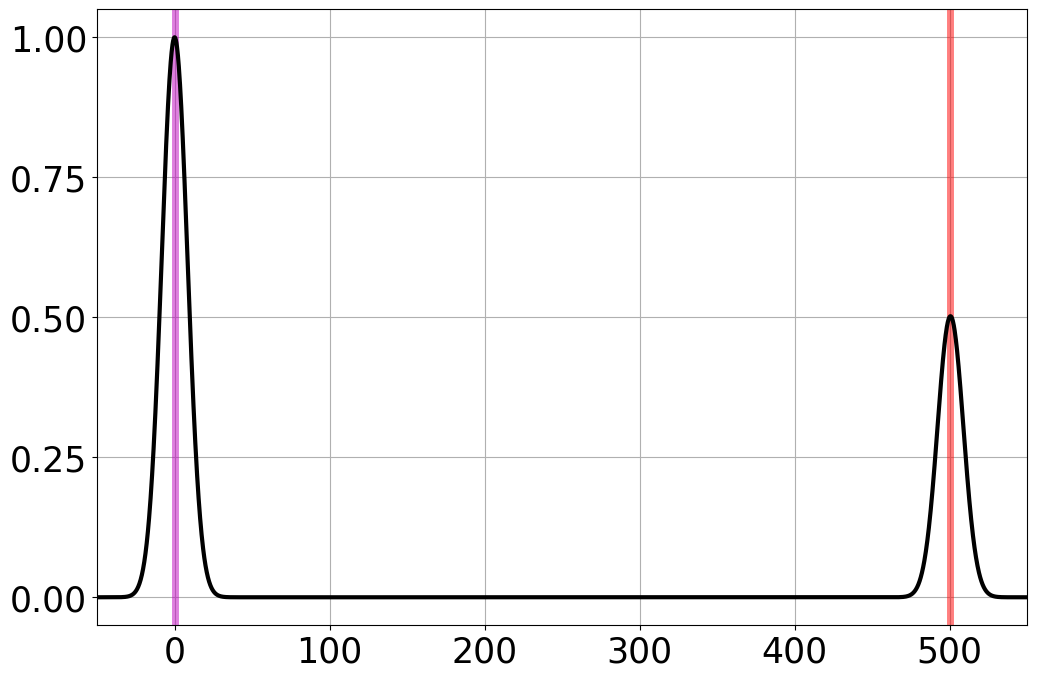

In [ ]:
# fig = plt.figure(1,figsize=(12,8))

# # plt.plot(vel_x,cross_sec_1,'k:',alpha=1,lw=3,label=r'$\sigma_{\rm R} = 2.5 ~ [\rm km\,s^{-1}]$')
# # plt.plot(vel_x, cross_sec_2, 'b-', markersize=0.5,label=r'30.0')
# # plt.plot(vel_x, cross_sec_3, 'r-', markersize=0.5,label=r'50.0 ')
# HH = (C_IV_H_A/ C_IV_K_A -1 ) *cc_k
# plt.axvline(0,ymin=-1,ymax=1,linestyle='-',color='m',alpha=0.5,lw=5)
# plt.axvline(HH,ymin=-1,ymax=1,linestyle='-',color='r',alpha=0.5,lw=5)
# # plt.yscale('log')
# plt.plot(vel_x,cross_sec / cross_sec.max(),'k-',lw=3,alpha=1,label=r'$ 11.8 $')
# plt.xlim(-50,550)
# # plt.ylim(1e-14,2e-13)
# # plt.ylabel(r'$\sigma_{\rm scr} ~ [\rm cm^{2}]$',fontsize=35)
# # plt.xlabel(r'$\Delta \rm V ~ [\rm km \, s^{-1}]$',fontsize=35)
# plt.yticks([0,0.25,0.5,0.75,1],fontsize=25)
# plt.xticks(fontsize=25)
# plt.grid(True)
# # plt.legend(loc='upper right',fontsize=25 , title=r'$\sigma_R ~ [\rm km \, s^{-1}]$',title_fontsize=30)
# # plt.savefig('/home/jin/바탕화면/Relative_flux.png',bbox_inches='tight')

In [ ]:
# dx= 0.05
# ii = np.where( (vel_x > 0-dx) & (vel_x < 0+dx) )[0]
# jj = np.where( (vel_x > 500-dx) & (vel_x < 500+dx) )[0]
# print(1/(cross_sec[ii]) ,cross_sec[jj])

[4.180876e+12] [1.97797269e-13]


In [ ]:
# fig = plt.figure(1,figsize=(12,10))
# # plt.plot(xx_H_2, voigt_H_2,'k:',alpha=1,lw=3,label=r'$\sigma_{\rm R} = 2.5 ~ [\rm km\,s^{-1}]$')
# plt.plot(xx_K, voigt_K,'k-',alpha=0.8,label=r'$\sigma_{\rm R} = 11.8 ~ [\rm km\,s^{-1}]$')
# # plt.plot(xx_K_2, voigt_K_2, 'b--', markersize=0.5,alpha=0.6,label=r'$\sigma_{\rm R} = 30.0 ~ [\rm km\,s^{-1}]$')
# # plt.plot(xx_K_3, voigt_K_3, 'r--', markersize=0.5,alpha=0.5,label=r'$\sigma_{\rm R} = 50.0 ~ [\rm km\,s^{-1}]$')
# plt.xlim(-5,5)
# # plt.ylabel(r'$\sigma_{\rm scr} ~ [\rm cm^{2}]$',fontsize=20)
# plt.xlabel(r'x',fontsize=20)
# plt.yticks(fontsize=15)
# plt.xticks(fontsize=15)
# plt.legend(loc='upper left',fontsize=20)
# # plt.savefig('/home/jin/바탕화면/voigt_profile_various_GR.pdf',bbox_inches='tight')

In [ ]:
# fig = plt.figure(1,figsize=(10,6))
# rr = np.arange(3, 22, 1, dtype=np.float128)
# atom_N = [13,20,32,50,79]
# total_N_c = np.outer(10**rr, atom_N) / 10
# total_N_c = total_N_c.flatten()

# plt.axvline(12,ymin=-10,ymax=10,linestyle='-',color='r')
# plt.axvline(17,ymin=-10,ymax=10,linestyle='-',color='r')
# W = np.zeros(len(total_N_c))
# W_1 = np.zeros(len(total_N_c))
# W_2 = np.zeros(len(total_N_c))
# for ii, n_civ in enumerate(total_N_c):
#     tau = n_civ*cross_sec
#     tau_1 = n_civ*cross_sec_1
#     tau_2 = n_civ*cross_sec_2
#     W[ii] = np.sum((1-np.exp(-tau)),0)
#     # W_1[ii] = np.sum((1-np.exp(-tau_1)),0)
#     # W_2[ii] = np.sum((1-np.exp(-tau_2)),0)


# # plt.plot(np.log10(total_N_c),np.log10(W_2),'k:',lw=2,label=r'$\sigma_{\rm R} = 2.5 ~ [\rm km\,s^{-1}]$')
# plt.plot(np.log10(total_N_c),np.log10(W),'k-',lw=3,label=r'$\sigma_{\rm R} = 11.8 ~ [\rm km\,s^{-1}]$')
# # plt.plot(np.log10(total_N_c),np.log10(W_1),'k--',lw=2,label=r'$\sigma_{\rm R} = 50.0 ~ [\rm km\,s^{-1}]$')
# # plt.legend(fontsize=15)
# # plt.

# plt.xlim(10.5,20.5)
# plt.ylim(-2.5,5.5)
# plt.yticks([-2,0,2,4],fontsize=30)
# plt.xticks(fontsize=30)
# plt.xlabel(r'$\log{N_{\rm CIV}}~[\rm cm^{-2}]$',fontsize=35)
# plt.ylabel(r'$\log{|W_{\rm EW}|}~[\rm \AA]$',fontsize=35)
# plt.minorticks_on()
# plt.grid(True)

# # plt.savefig('/home/jin/바탕화면/curve_of_growth.pdf',bbox_inches="tight")